### 1. 离散阻滞增长模型的单调收敛、振荡收敛、倍周期分叉和混沌曲线(r很大)

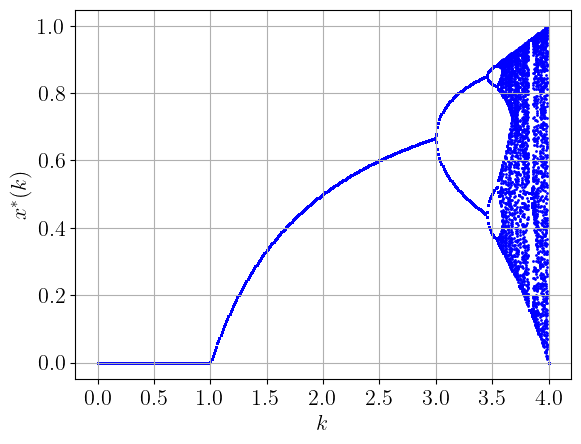

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

logistic = lambda k, x: k * x * (1 - x)  # k=r,x=N_t/K（现在数量/最大承载）
kk = np.arange(0, 4.01, 0.01)
listk = []
listx = []

for k in kk:
    x = 0.5
    for i in range(1, 500):
        x1 = logistic(k, x) 
        x = x1
        if i > 400:  # 前400次迭代作为"瞬态"被忽略，使系统达到稳定状态，记录接下来的100次迭代值作为系统的稳定行为
            listk.append(k)
            listx.append(x)
            
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 16

plt.scatter(listk, listx, c='b', s=1)
plt.grid(True)
plt.xticks(np.arange(0, 4.01, 0.5))
plt.xlabel("$k$")
plt.ylabel("$x^*(k)$")
plt.show()

例 13.6 表 13.5 的数据是从测量酵母培养物增长的实验收集而来的, 请建立数学模型, 模拟酵母培养物的增长过程.

**表 13.5 酵母培养物增长的实验数据**

| 时刻/h | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 生物量/g | 9.6 | 18.3 | 29.0 | 47.2 | 71.1 | 119.1 | 174.6 | 257.3 | 350.7 | 441.0 |
| 时刻/h | 10 | 11 | 12 | 13 | 14 | 15 | 16 | 17 | 18 |  |
| 生物量/g | 513.3 | 559.7 | 594.8 | 629.4 | 640.8 | 651.1 | 655.9 | 659.6 | 661.8 |  |

### 1. 问题分析

记表 13.5 中的第 $ k $ 小时的酵母生物量为 $ x_k \text{g} (k = 0, 1, \cdots, 18) $. 为了构建数学模型, 首先绘制 $ x_k $ 关于 $ k $ 的散点图见图 13.4. 观测 $ x_k $ 关于 $ k $ 的散点图, 可以发现 $ x_k $ 关于 $ k $ 的散点沿 S 形曲线分布, $ x_k $ 随着 $ k $ 单调增加, $ x_k $ 可能趋于稳定值. 因而选择离散 Logistic 模型研究酵母生物量的变化趋势.

### 2. 模型的建立与求解

根据上述问题分析, 选择离散 Logistic 模型
$$ 
x_{k + 1} = x_k + r x_k \left(1 - \frac{x_k}{N}\right), \quad k = 0, 1, 2, \cdots, \tag{13.23} 
$$
其中, $ r $ 为固有增长率, $ N $ 为系统最大容量.

要求解模型, 需要先拟合模型中的未知参数 $ r, N $, 使用最小二乘法拟合参数 $ r, N $. 首先把 (13.23) 式改写为
$$ 
r x_k - s x_k^2 = x_{k + 1} - x_k, \tag{13.24} 
$$
其中, $ s = \frac{r}{N} $, 把已知的 19 个观测值代入 (13.24) 式, 得到关于 $ r, s $ 的超定线性方程组
$$ 
\begin{bmatrix} x_0 & -x_0^2 \\ x_1 & -x_1^2 \\ \vdots & \vdots \\ x_{17} & -x_{17}^2 \end{bmatrix} \begin{bmatrix} r \\ s \end{bmatrix} = \begin{bmatrix} x_1 - x_0 \\ x_2 - x_1 \\ \vdots \\ x_{18} - x_{17} \end{bmatrix}. \tag{13.25} 
$$

利用 Python 软件, 求得 $ r = 0.5577 $, $ s = 0.00085 $, $ N = 654.0487 $.

已知原始数据和拟合值对比如图 13.5 所示, 其他计算结果就不列举了.

## 3. 模型检验与评价

经检验模型对已知点预测的最大相对误差为 31.47\%, 也就是中间数据点的预测值的偏差有点大, 模型还有进一步改进的必要.


离散 Logistic 模型不仅可以应用于酵母培养物的变化趋势研究, 还可以应用于其他具有 S 形变化趋势的种群问题.


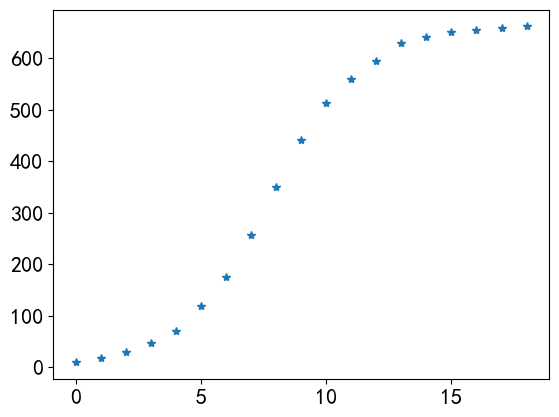

内禀系数r, s=r/N, 最大容量N的拟合值分别为: 0.557685110296146, 0.000852666006998164, 654.0487198023678


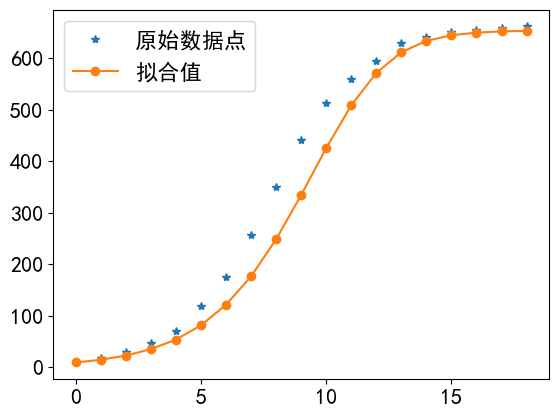

所有已知的预测值的相对误差为:
[0.         0.18714779 0.20751036 0.25108755 0.24055326 0.3146622
 0.30433425 0.31355683 0.29135431 0.24159705 0.17086125 0.09147712
 0.03899245 0.02798153 0.01087147 0.0097392  0.00919947 0.01124355
 0.01296336]
最大相对误差: 0.3146622036442505


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

a = np.loadtxt("Pdata13_6.txt")  # 酵母菌生物量数据(0~18)

plt.rcParams['font.size'] = 16
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['text.usetex'] = False

plt.plot(np.arange(0, 19), a, '*')
plt.show()

b = np.c_[a[:-1], -a[:-1]**2]  # (19, 2)
c = np.diff(a)  # 离散差分，求相邻元素的差
x= np.linalg.pinv(b).dot(c)  # pinv(b)求伪逆
r = x[0]
N = x[0] / x[1]

print(f"内禀系数r, s=r/N, 最大容量N的拟合值分别为: {r}, {x[1]}, {N}")

Tx = np.zeros(19)  # (19,)
Tx[0] = 9.6  # 拟合酵母菌生物量的第一个数据，索引0
x0 = 9.6  # 酵母菌生物量第一个数据
for i in range(1, 19):  # 索引1~18个数据
    xn = x0 + r * x0 * (1 - x0 / N)  # x_k+1 = x_k + r*x_k(1-x_k/N)
    Tx[i] = xn
    x0 = xn
    
plt.figure()  # 创建新figure,避免画在上一幅图
plt.plot(np.arange(0, 19), a, '*')
plt.plot(np.arange(19), Tx, 'o-')
plt.legend(("原始数据点", "拟合值"), loc='best')
plt.show()

delta = np.abs((Tx - a) / a)
print(f"所有已知的预测值的相对误差为:\n{delta}")
print(f"最大相对误差: {delta.max()}")